# Exploration — Gumbel vs Empirical Return Period Comparison

Compares Gumbel-fitted return period thresholds against purely empirical (Weibull plotting position) estimates for both data sources used in the readiness and action triggers:

- **GloFAS reanalysis** — one station per state (Wuroboki / Makurdi)
- **GRRR reanalysis** — all selected gauges from Step 4

Plots show observed annual maxima (points) against the fitted Gumbel curve, with reference lines at RP = 2, 3, 5 years. Wet-season annual maxima (Aug–Nov) are used throughout, consistent with the workflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from scipy import stats as scipy_stats

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.datasources.glofas import get_blob_name

load_dotenv()

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
STATES     = ["Adamawa", "Benue"]
WET_MONTHS = [8, 9, 10, 11]
RP_MARKS   = [2, 3, 4, 5]

FIGURES_DIR = Path("figures/exploration")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def gumbel_vs_empirical(annual_maxima):
    """Empirical (Weibull) and Gumbel RP comparison for annual maxima."""
    vals = np.sort(np.asarray(annual_maxima, dtype=float))[::-1]
    n = len(vals)
    emp_rp = (n + 1) / np.arange(1, n + 1)  # Weibull: largest obs gets highest RP
    loc, scale = scipy_stats.gumbel_r.fit(vals)
    rp_smooth = np.logspace(np.log10(1.05), 2, 300)
    fit_vals  = scipy_stats.gumbel_r.ppf(1 - 1 / rp_smooth, loc=loc, scale=scale)
    return {
        "emp_rp":   emp_rp,
        "emp_vals": vals,
        "rp_smooth": rp_smooth,
        "fit_vals":  fit_vals,
        "loc":   loc,
        "scale": scale,
        "n":     n,
    }

## GloFAS Reanalysis

In [4]:
glofas = {}
for state in STATES:
    cfg     = STATE_CONFIG[state]
    blob_ra = get_blob_name("processed", "reanalysis", cfg["glofas_station"])
    df_ra   = stratus.load_parquet_from_blob(blob_ra)
    df_ra["time"]  = pd.to_datetime(df_ra["time"])
    df_ra["year"]  = df_ra["time"].dt.year
    df_ra["month"] = df_ra["time"].dt.month
    dis_col = next(c for c in df_ra.columns if c.lower() in ("dis24", "discharge"))

    df_wet  = df_ra[
        df_ra["month"].isin(WET_MONTHS)
        & df_ra["year"].between(cfg["analysis_start_year"], cfg["analysis_end_year"])
    ]
    ann_max = df_wet.groupby("year")[dis_col].max().values

    glofas[state] = {
        "station": cfg["glofas_station"],
        "fit":     gumbel_vs_empirical(ann_max),
    }
    print(f"{state} ({cfg['glofas_station']}): n = {len(ann_max)} years")

Adamawa (wuroboki): n = 26 years
Benue (makurdi): n = 26 years


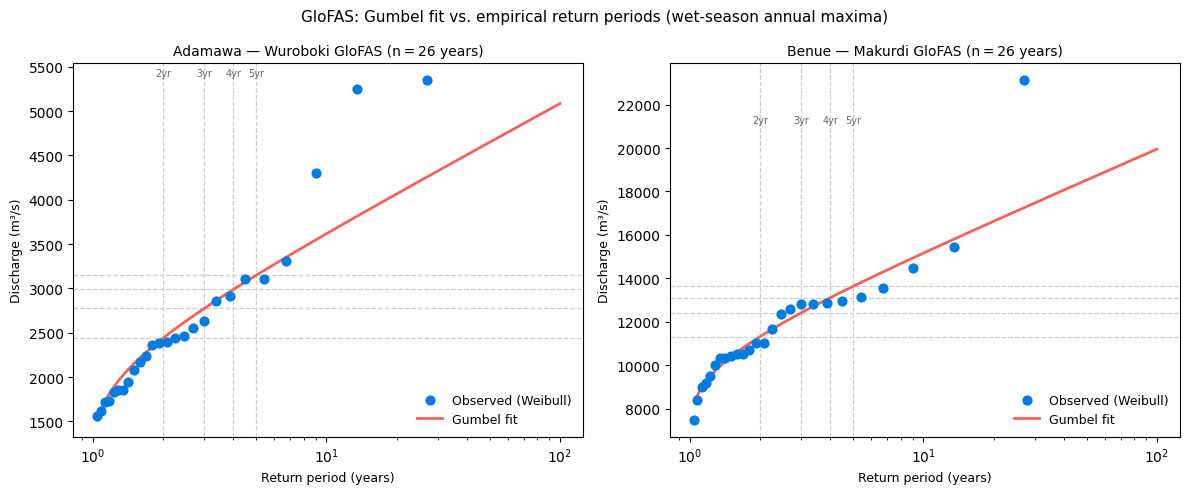

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, state in zip(axes, STATES):
    d   = glofas[state]
    fit = d["fit"]

    ax.scatter(
        fit["emp_rp"], fit["emp_vals"],
        color="#007CE0", s=40, zorder=5, label="Observed (Weibull)",
    )
    ax.plot(
        fit["rp_smooth"], fit["fit_vals"],
        color="#F2645A", linewidth=2, label="Gumbel fit",
    )

    y_top = fit["fit_vals"].max() * 1.08
    for rp in RP_MARKS:
        rp_val = float(
            scipy_stats.gumbel_r.ppf(1 - 1 / rp, fit["loc"], fit["scale"])
        )
        ax.axvline(rp, color="#CCCCCC", linewidth=0.9, linestyle="--", zorder=0)
        ax.axhline(rp_val, color="#CCCCCC", linewidth=0.9, linestyle="--", zorder=0)
        ax.text(
            rp, y_top, f"{rp}yr",
            fontsize=7, color="#666666", ha="center", va="top",
        )

    ax.set_xscale("log")
    ax.set_xlabel("Return period (years)", fontsize=9)
    ax.set_ylabel("Discharge (m\u00b3/s)", fontsize=9)
    ax.set_title(
        f"{state} \u2014 {d['station'].title()} GloFAS"
        f" (n\u2009=\u2009{fit['n']} years)",
        fontsize=10,
    )
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    "GloFAS: Gumbel fit vs. empirical return periods (wet-season annual maxima)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "exploration_rp_comparison_glofas.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## GRRR Reanalysis (Selected Gauges)

Each panel shows one selected gauge (from Step 4). Points are observed wet-season annual maxima with Weibull plotting positions; the red line is the fitted Gumbel distribution.

In [6]:
grrr_data = {}
for state in STATES:
    cfg      = STATE_CONFIG[state]
    blob_sel = (
        f"{PROJECT_PREFIX}/processed/workflow/"
        f"{state.lower()}_selected_gauges.parquet"
    )
    df_sel    = stratus.load_parquet_from_blob(blob_sel)
    gauge_ids = df_sel[df_sel["source"] == "grrr"]["gauge_id"].tolist()

    ds_ra  = grrr.load_reanalysis(gauge=gauge_ids)
    df_ra  = grrr.process_reanalysis(ds_ra)
    df_ra["date"]  = pd.to_datetime(df_ra["valid_time"]).dt.normalize()
    df_ra["year"]  = df_ra["date"].dt.year
    df_ra["month"] = df_ra["date"].dt.month

    df_wet = df_ra[
        df_ra["month"].isin(WET_MONTHS)
        & df_ra["year"].between(cfg["analysis_start_year"], cfg["analysis_end_year"])
    ]

    gauge_fits = {}
    for gid in gauge_ids:
        ann_max = (
            df_wet[df_wet["gauge_id"] == gid]
            .groupby("year")["streamflow"]
            .max()
            .values
        )
        if len(ann_max) >= 5:
            gauge_fits[gid] = gumbel_vs_empirical(ann_max)

    grrr_data[state] = {"gauge_ids": gauge_ids, "fits": gauge_fits}
    print(f"{state}: {len(gauge_fits)}/{len(gauge_ids)} gauges with sufficient data")

I0603 15:29:39.236823 7945530 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0603 15:29:39.247141 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247188 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247191 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247193 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247195 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247199 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247201 7945546 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
I0603 15:29:39.247203 7945546 ev_poll_posix.cc:593] FD from fork parent sti

Adamawa: 10/10 gauges with sufficient data
Benue: 10/10 gauges with sufficient data


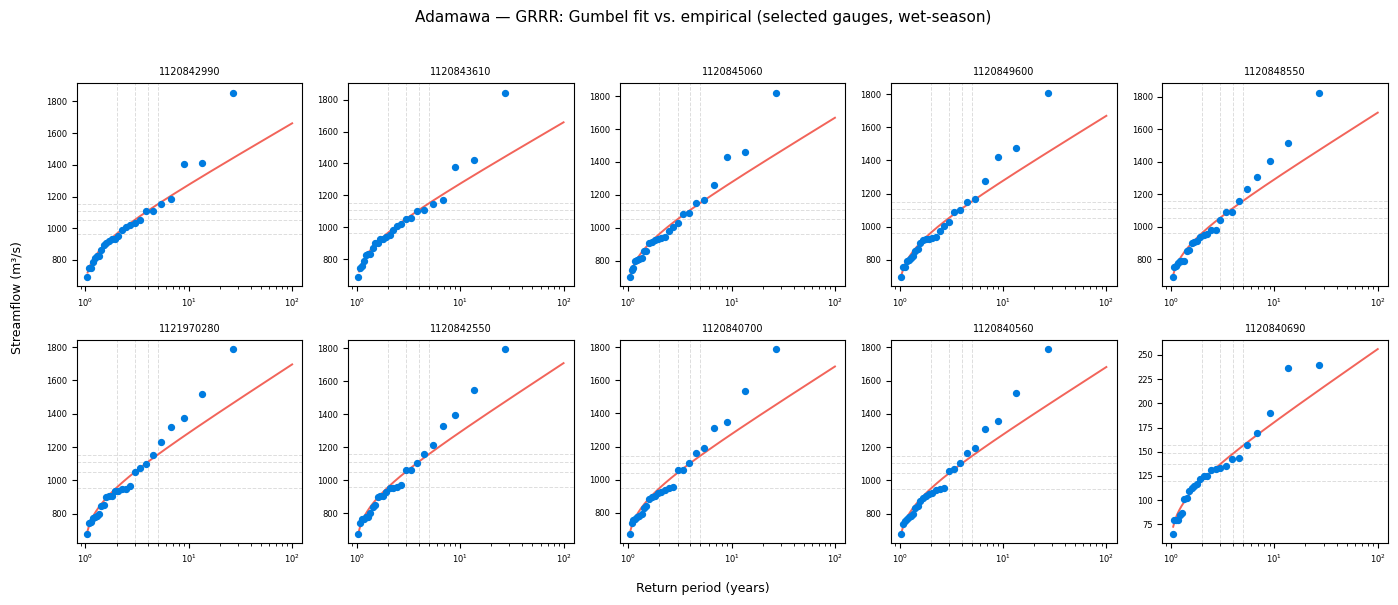

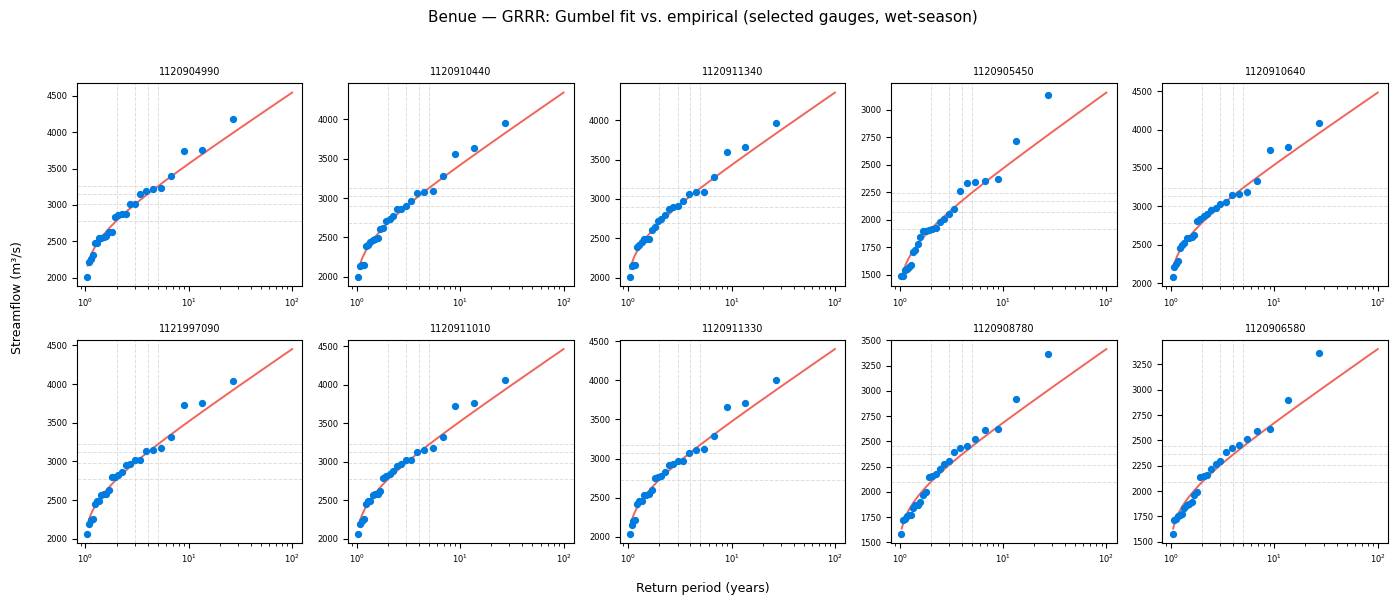

In [7]:
N_COLS = 5

for state in STATES:
    d          = grrr_data[state]
    gauge_ids  = d["gauge_ids"]
    n          = len(gauge_ids)
    n_rows     = int(np.ceil(n / N_COLS))

    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * 2.8, n_rows * 3.0))
    axes_flat = axes.flatten()

    for i, gid in enumerate(gauge_ids):
        ax = axes_flat[i]
        if gid not in d["fits"]:
            ax.set_visible(False)
            continue
        fit = d["fits"][gid]

        ax.scatter(
            fit["emp_rp"], fit["emp_vals"],
            color="#007CE0", s=18, zorder=5,
        )
        ax.plot(
            fit["rp_smooth"], fit["fit_vals"],
            color="#F2645A", linewidth=1.4,
        )

        for rp in RP_MARKS:
            rp_val = float(
                scipy_stats.gumbel_r.ppf(1 - 1 / rp, fit["loc"], fit["scale"])
            )
            ax.axvline(rp, color="#DDDDDD", linewidth=0.7, linestyle="--", zorder=0)
            ax.axhline(rp_val, color="#DDDDDD", linewidth=0.7, linestyle="--", zorder=0)

        ax.set_xscale("log")
        ax.set_title(gid.split("_")[-1], fontsize=7)
        ax.tick_params(labelsize=6)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(
        f"{state} \u2014 GRRR: Gumbel fit vs. empirical (selected gauges, wet-season)",
        fontsize=11,
    )
    fig.text(0.5, 0.01, "Return period (years)", ha="center", fontsize=9)
    fig.text(0.005, 0.5, "Streamflow (m\u00b3/s)", va="center", rotation="vertical", fontsize=9)

    plt.tight_layout(rect=[0.02, 0.03, 1, 0.96])
    plt.savefig(
        FIGURES_DIR / f"exploration_rp_comparison_grrr_{state.lower()}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()